## Contents:
1. data retrieval and transformation
2. figure generation of index, return plot and histogram 
3. tests for normality
4. tests for autocorrelation
5. Volatility clustering inspection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter
import yfinance as yf

In [1]:
import os

print(os.getcwd())

c:\Users\finle\Dev\Dissertation\notebooks


## Retreival

In [ ]:
data = yf.download("^GSPC",
                   start="2005-01-01",
                   end="2025-01-01",
                   interval="1d")


pd.DataFrame(data)
print(data.head())
print(data.tail())

data.to_csv("SPY_data.csv")

In [ ]:
spy = pd.read_csv(
                  "data/SPY_data.csv",
                  index_col=0,
                  parse_dates=[0],
                  date_format=r'%Y-%m-%d')

spy.index = pd.to_datetime(
                           spy.index,
                           format=r'%Y-%m-%d',
                           errors='coerce')

print(spy.head())

                  Close         High          Low         Open      Volume  \
Price                                                                        
2005-01-03  1202.079956  1217.800049  1200.319946  1211.920044  1510800000   
2005-01-04  1188.050049  1205.839966  1185.390015  1202.079956  1721000000   
2005-01-05  1183.739990  1192.729980  1183.719971  1188.050049  1738900000   
2005-01-06  1187.890015  1191.630005  1183.270020  1183.739990  1569100000   
2005-01-07  1186.189941  1192.199951  1182.160034  1187.890015  1477900000   

            log_returns  
Price                    
2005-01-03          NaN  
2005-01-04    -1.174000  
2005-01-05    -0.363444  
2005-01-06     0.349973  
2005-01-07    -0.143220  


In [5]:
close = pd.to_numeric(
                      spy['Close'],
                      errors='coerce')

print(spy.head())
print(type(spy.index))

                  Close         High          Low         Open      Volume  \
Price                                                                        
2005-01-03  1202.079956  1217.800049  1200.319946  1211.920044  1510800000   
2005-01-04  1188.050049  1205.839966  1185.390015  1202.079956  1721000000   
2005-01-05  1183.739990  1192.729980  1183.719971  1188.050049  1738900000   
2005-01-06  1187.890015  1191.630005  1183.270020  1183.739990  1569100000   
2005-01-07  1186.189941  1192.199951  1182.160034  1187.890015  1477900000   

            log_returns  
Price                    
2005-01-03          NaN  
2005-01-04    -1.174000  
2005-01-05    -0.363444  
2005-01-06     0.349973  
2005-01-07    -0.143220  
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [ ]:
print("Summary statistics:")
print(close.describe())

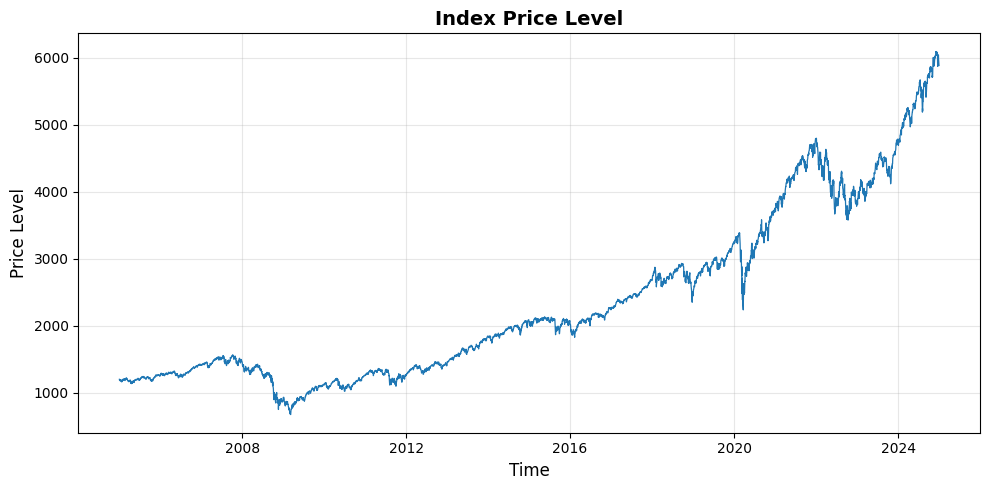

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(close, linewidth=0.9)

ax.set_title("Index Price Level", fontsize=14, fontweight='bold')
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Price Level", fontsize=12)

ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("tables/Index_price_level.pdf", dpi=600, bbox_inches="tight")
plt.show()


Log returns:
Price
2005-01-04   -1.174000
2005-01-05   -0.363444
2005-01-06    0.349973
2005-01-07   -0.143220
2005-01-10    0.341693
                ...   
2024-12-24    1.098223
2024-12-26   -0.040574
2024-12-27   -1.111730
2024-12-30   -1.075967
2024-12-31   -0.429401
Name: Close, Length: 5032, dtype: float64

 Summary Statistics (returns)
count    5032.000000
mean        0.031554
std         1.210385
min       -12.765220
25%        -0.409304
50%         0.071127
75%         0.570478
max        10.957197
Name: Close, dtype: float64


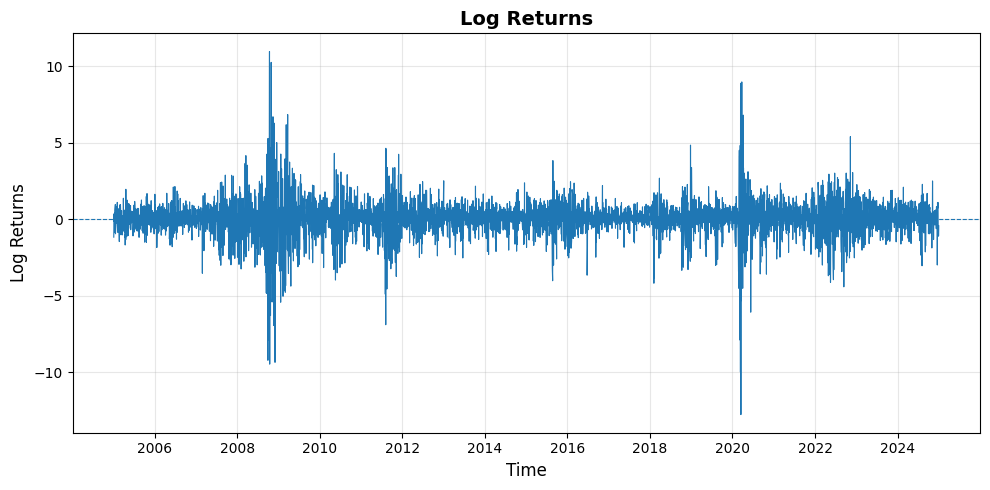

In [ ]:
log_returns = np.log(close / close.shift(1)).dropna()
log_returns = 100*log_returns
spy['log_returns'] = log_returns
spy.to_csv('SPY_data.csv')

print("\nLog returns:")
print(log_returns)
print("\n Summary Statistics (returns)")
print(log_returns.describe())

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(log_returns, linewidth=0.8)
ax.set_title("Log Returns", fontsize=14, fontweight="bold")
ax.set_ylabel("Log Returns", fontsize=12)
ax.set_xlabel("Time", fontsize=12)
ax.axhline(0,linestyle='--', linewidth=0.8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
ax.xaxis.set_major_locator(YearLocator(2))
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
fig.savefig("tables/log_returns.pdf", dpi=600, bbox_inches="tight")


In [10]:
print("Summary statistics:")
print(log_returns.describe())

Summary statistics:
count    5032.000000
mean        0.031554
std         1.210385
min       -12.765220
25%        -0.409304
50%         0.071127
75%         0.570478
max        10.957197
Name: Close, dtype: float64


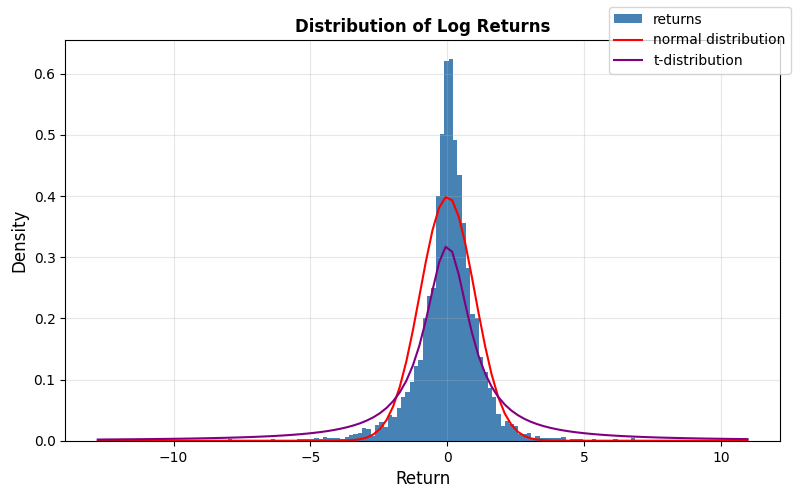

In [ ]:
from scipy.stats import norm, t

x = np.linspace(min(log_returns), max(log_returns), 100)
pdfs = [norm.pdf(x), t.pdf(x,df=1)]

fig, ax = plt.subplots(figsize=(8,5))
ax.set_title("Distribution of Log Returns", fontweight="bold")

ax.hist(log_returns, bins=150, density=True, color='steelblue', label='returns')
ax.set_xlabel("Return", fontsize=12)
ax.set_ylabel("Density", fontsize=12)

ax.plot(x, pdfs[0], color='red', label='normal distribution')
ax.plot(x,pdfs[1], color='purple', label='t-distribution')

fig.tight_layout()
ax.grid(True, alpha=0.3)
fig.legend()
fig.savefig("tables/histogram_of_log_returns.pdf", dpi=600, bbox_inches="tight")
plt.show()

## Normality test

In [ ]:
from statsmodels.stats.stattools import jarque_bera

def jb_test(timeseries):
    print("\nResults for Jarque-Bera Test:")
    jb = jarque_bera(timeseries)
    output = pd.Series(
        jb, index=["Test Statistic", 
                "p-value", "Skew", "Kurtosis"
                ]
    )
    print(output)
    
    

jb_test(log_returns)

## Tests for stationarity

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)
    
adf_test(log_returns)


# Test for Autocorrelation

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt


fig, ax = plt.subplots()
plot_acf(log_returns, zero=False, ax=ax)
ax.set_title("ACF of Returns", fontsize=14, fontweight="bold")
fig.tight_layout()
ax.set_ylim(-0.25,0.25)
fig.savefig("tables/ACF_of_Returns.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt


fig, ax = plt.subplots()
plot_acf(log_returns **2, zero=False, ax=ax)
ax.set_title("ACF of Squared returns", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig("tables/ACF_Squared_Returns.pdf", dpi=600, bbox_inches="tight")

#ax.set_ylim(-0.25,0.25)

plt.show()

## Volatility clustering

In [ ]:
fig, ax = plt.subplots()
ax.plot(log_returns ** 2, color='steelblue')
ax.set_title("Squared Returns")
ax.set_xlabel("Time")
ax.set_ylabel(r"$r^2$")
plt.show()

## ARCH LM test

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_arch



ar_model = ARIMA(log_returns, order=(1,0,0), trend='n')

ar_res = ar_model.fit()

residuals = ar_res.resid

# Step 3: Perform ARCH LM test on residuals using statsmodels
lm_test_stat, lm_test_pvalue, f_test_stat, f_test_pvalue = het_arch(residuals, nlags=5)

print(f"ARCH LM test statistic: {lm_test_stat}")
print(f"ARCH LM test p-value: {lm_test_pvalue}")